# Morphological Operators

This notebook demonstrates the four morphological raster operators
in `xrspatial.morphology`:

- **`morph_erode`** -- local minimum (shrinks bright regions)
- **`morph_dilate`** -- local maximum (expands bright regions)
- **`morph_opening`** -- erosion then dilation (removes small bright features)
- **`morph_closing`** -- dilation then erosion (fills small dark gaps)

These operations work on any numeric raster, including grayscale
elevation data and binary classification masks.  All four backends
(numpy, cupy, dask+numpy, dask+cupy) are supported.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from xrspatial.morphology import (
    _circle_kernel,
    morph_closing,
    morph_dilate,
    morph_erode,
    morph_opening,
)

## 1. Synthetic elevation data

Create a small raster with a peak and a pit to show how erosion and
dilation behave.

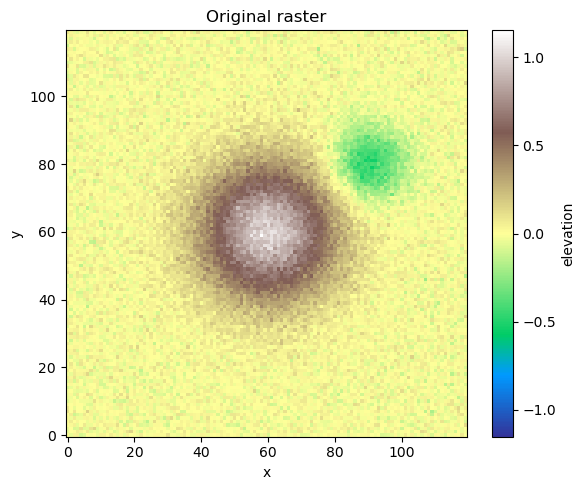

In [2]:
rng = np.random.default_rng(42)
y, x = np.mgrid[-3:3:0.05, -3:3:0.05]
z = np.exp(-(x**2 + y**2)) - 0.5 * np.exp(-((x - 1.5)**2 + (y - 1)**2) / 0.3)
z += 0.05 * rng.standard_normal(z.shape)  # add noise

raster = xr.DataArray(z, dims=['y', 'x'], name='elevation')

fig, ax = plt.subplots(figsize=(6, 5))
raster.plot(ax=ax, cmap='terrain')
ax.set_title('Original raster')
plt.tight_layout()
plt.show()

## 2. Erosion and dilation

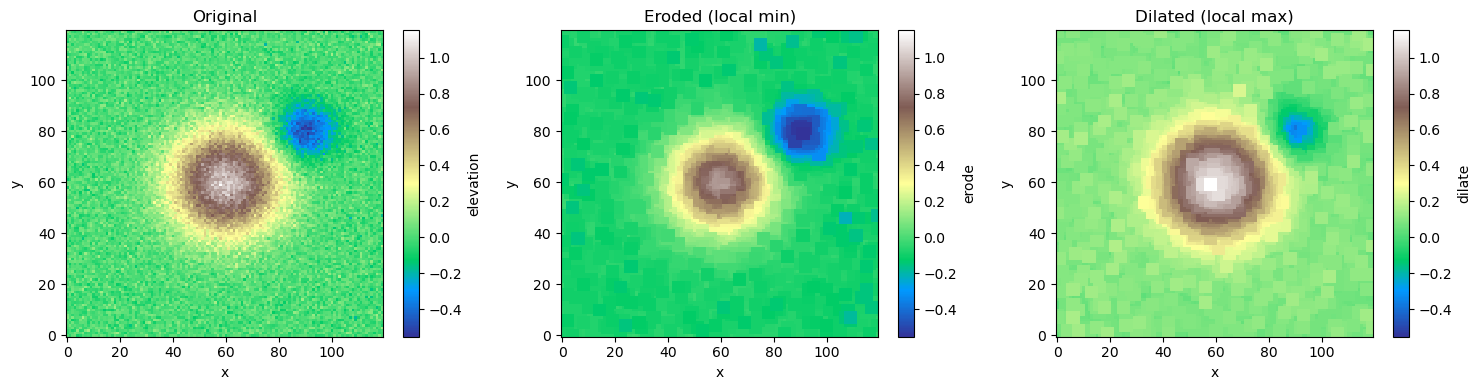

In [3]:
kernel = np.ones((5, 5), dtype=np.uint8)

eroded = morph_erode(raster, kernel=kernel, boundary='nearest')
dilated = morph_dilate(raster, kernel=kernel, boundary='nearest')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(
    axes,
    [raster, eroded, dilated],
    ['Original', 'Eroded (local min)', 'Dilated (local max)'],
):
    data.plot(ax=ax, cmap='terrain', vmin=z.min(), vmax=z.max())
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 3. Opening and closing

Opening removes small bright spikes; closing fills small dark pits.

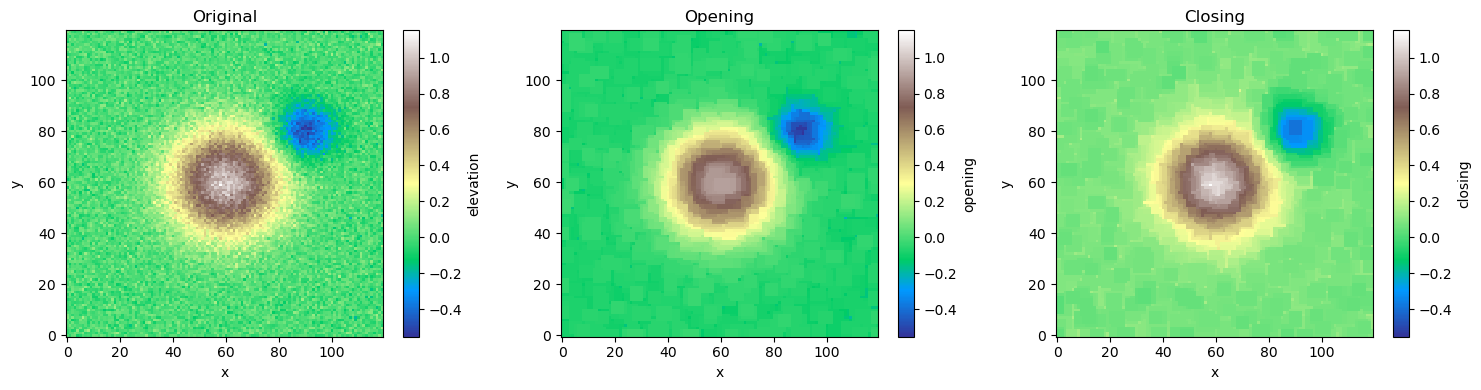

In [4]:
opened = morph_opening(raster, kernel=kernel, boundary='nearest')
closed = morph_closing(raster, kernel=kernel, boundary='nearest')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(
    axes,
    [raster, opened, closed],
    ['Original', 'Opening', 'Closing'],
):
    data.plot(ax=ax, cmap='terrain', vmin=z.min(), vmax=z.max())
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 4. Binary mask cleanup

A common use case: clean up noisy classification results.  Opening
removes salt noise; closing removes pepper noise.

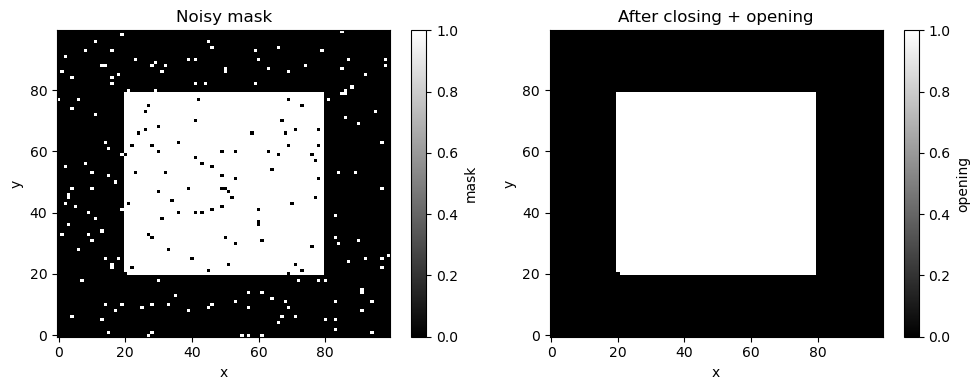

In [5]:
# Generate a binary mask with noise
mask = np.zeros((100, 100), dtype=np.float64)
mask[20:80, 20:80] = 1.0  # large square

# Sprinkle salt-and-pepper noise
noise = rng.random(mask.shape)
mask[noise < 0.02] = 1.0   # salt
mask[noise > 0.98] = 0.0   # pepper

noisy = xr.DataArray(mask, dims=['y', 'x'], name='mask')
cleaned = morph_opening(
    morph_closing(noisy, kernel=kernel, boundary='nearest'),
    kernel=kernel,
    boundary='nearest',
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
noisy.plot(ax=axes[0], cmap='gray')
axes[0].set_title('Noisy mask')
cleaned.plot(ax=axes[1], cmap='gray')
axes[1].set_title('After closing + opening')
plt.tight_layout()
plt.show()

## 5. Circular structuring element

Use `_circle_kernel(radius)` to create a disk-shaped kernel
instead of a square.

Circular kernel (radius=3):
[[0 0 0 1 0 0 0]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [0 0 0 1 0 0 0]]


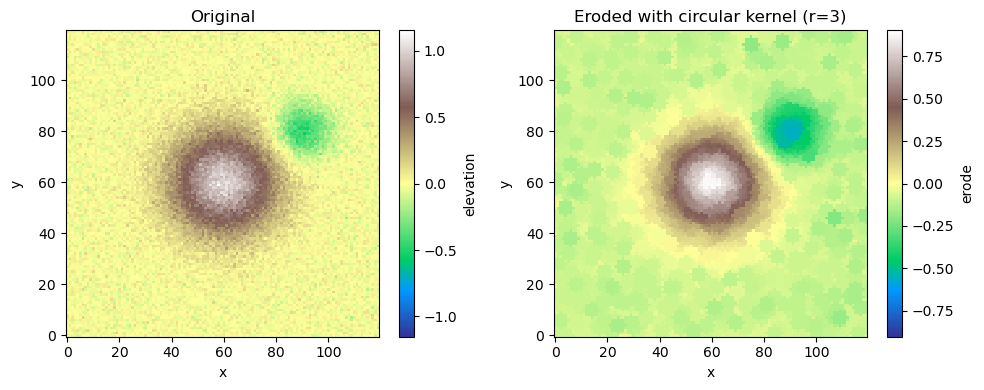

In [6]:
disk = _circle_kernel(3)
print('Circular kernel (radius=3):')
print(disk)

eroded_disk = morph_erode(raster, kernel=disk, boundary='nearest')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
raster.plot(ax=axes[0], cmap='terrain')
axes[0].set_title('Original')
eroded_disk.plot(ax=axes[1], cmap='terrain')
axes[1].set_title('Eroded with circular kernel (r=3)')
plt.tight_layout()
plt.show()